In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directories to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'parameters'))
sys.path.insert(0, os.getcwd())

from analysis_utils import (
    load_best_runs,
    load_top_n_runs,
    extract_history,
    add_wall_times,
    plot_2d_histograms,
    plot_convergence_curves,
    plot_time_to_best,
    plot_speedrun_results,
    plot_performance_summary,
    print_speedrun_table,
    print_best_hyperparameters,
    save_best_hyperparameters,
    get_optimizer_colors,
    ALL_OPTIMIZERS,
)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configuration


In [2]:
# Backend: "wandb" or "local"
BACKEND = "local"

# WandB settings (ignored if BACKEND == "local")
PROJECT = "induced_metric"
ENTITY = "thomas_harvey"  # Change to your WandB entity

# Task settings
TASK_TAG = "mnist_mlp"
ITERATION = 4  # Iteration/batch number to load results from

# Optimizers to analyse
# OPTIMIZERS = ['adam', 'adamw', 'sgd', 'sgd_metric', 'sgd_log_metric', 'muon', 'sgd_rms']
OPTIMIZERS = ALL_OPTIMIZERS  # Uncomment to analyse all optimizers

# Results directory (for local backend)
RESULTS_DIR = os.path.join('..', 'results')

# Metric configuration
SORT_METRIC = "final_max_val_acc"   # WandB summary metric to sort by
SORT_ORDER = "-"                     # "-" descending (higher accuracy = better)
METRIC_KEY = "sweep_metric"          # Local backend sorting key
DIRECTION = "minimize"               # sweep_metric is -accuracy, so lower is better

# Speedrun targets (test accuracy thresholds)
SPEEDRUN_TARGETS = [0.85, 0.90, 0.92, 0.94, 0.96, 0.97, 0.975]
SPEEDRUN_DIRECTION = "above"         # Metric must go ABOVE target
SPEEDRUN_METRIC = "test_acc"

# History metrics to extract
HISTORY_METRICS = ["train_loss", "train_acc", "test_acc", "train_time_seconds"]

# 2D histogram axes
HIST_X = "final_max_acc_epoch"
HIST_Y = "final_max_val_acc"

# Time-to-best keys
BEST_EPOCH_KEY = "final_max_acc_epoch"
BEST_METRIC_KEY = "test_acc"

colors = get_optimizer_colors(OPTIMIZERS)
print(f"Backend: {BACKEND}")
print(f"Task: {TASK_TAG}, Iteration: {ITERATION}")
print(f"Optimizers: {OPTIMIZERS}")

Backend: local
Task: mnist_mlp, Iteration: 4
Optimizers: ['adam', 'adamw', 'sgd', 'muon', 'sgd_metric', 'sgd_log_metric', 'sgd_rms', 'sgd_learn_scalar', 'sgd_learn_scalar_log', 'sgd_learn_diag', 'sgd_learn_diag_log', 'sgd_offdiag_0_l', 'sgd_offdiag_0_m', 'sgd_offdiag_0_theta', 'sgd_offdiag_l_0', 'sgd_offdiag_l_l', 'sgd_offdiag_l_m', 'sgd_offdiag_l_theta', 'sgd_offdiag_m_0', 'sgd_offdiag_m_l', 'sgd_offdiag_m_m', 'sgd_offdiag_m_theta', 'sgd_offdiag_theta_0', 'sgd_offdiag_theta_l', 'sgd_offdiag_theta_m', 'sgd_offdiag_theta_theta']


# Load Data


In [3]:
best_runs = load_best_runs(
    backend=BACKEND,
    optimizers=OPTIMIZERS,
    task_tag=TASK_TAG,
    project=PROJECT,
    entity=ENTITY,
    results_dir=RESULTS_DIR,
    metric_key=METRIC_KEY,
    direction=DIRECTION,
    sort_metric=SORT_METRIC,
    sort_order=SORT_ORDER,
    iteration=ITERATION,
)

top_n_runs = load_top_n_runs(
    backend=BACKEND,
    optimizers=OPTIMIZERS,
    n=50,
    task_tag=TASK_TAG,
    project=PROJECT,
    entity=ENTITY,
    results_dir=RESULTS_DIR,
    metric_key=METRIC_KEY,
    direction=DIRECTION,
    sort_metric=SORT_METRIC,
    sort_order=SORT_ORDER,
    iteration=ITERATION,
)

print(f"\nLoaded best runs for {len(best_runs)} optimizers")

Finding best run for adam...
  adam: run_167
Finding best run for adamw...
  adamw: run_970
Finding best run for sgd...
  sgd: run_98
Finding best run for muon...
  muon: run_13
Finding best run for sgd_metric...
  sgd_metric: run_404
Finding best run for sgd_log_metric...
  sgd_log_metric: run_668
Finding best run for sgd_rms...
  sgd_rms: run_391
Finding best run for sgd_learn_scalar...
  sgd_learn_scalar: run_317
Finding best run for sgd_learn_scalar_log...
  sgd_learn_scalar_log: run_488
Finding best run for sgd_learn_diag...
  sgd_learn_diag: run_304
Finding best run for sgd_learn_diag_log...
  sgd_learn_diag_log: run_488
Finding best run for sgd_offdiag_0_l...
  sgd_offdiag_0_l: run_79
Finding best run for sgd_offdiag_0_m...
  sgd_offdiag_0_m: run_621
Finding best run for sgd_offdiag_0_theta...
  sgd_offdiag_0_theta: run_794
Finding best run for sgd_offdiag_l_0...
  sgd_offdiag_l_0: run_179
Finding best run for sgd_offdiag_l_l...
  sgd_offdiag_l_l: run_687
Finding best run for sg

# Distribution of Top Runs


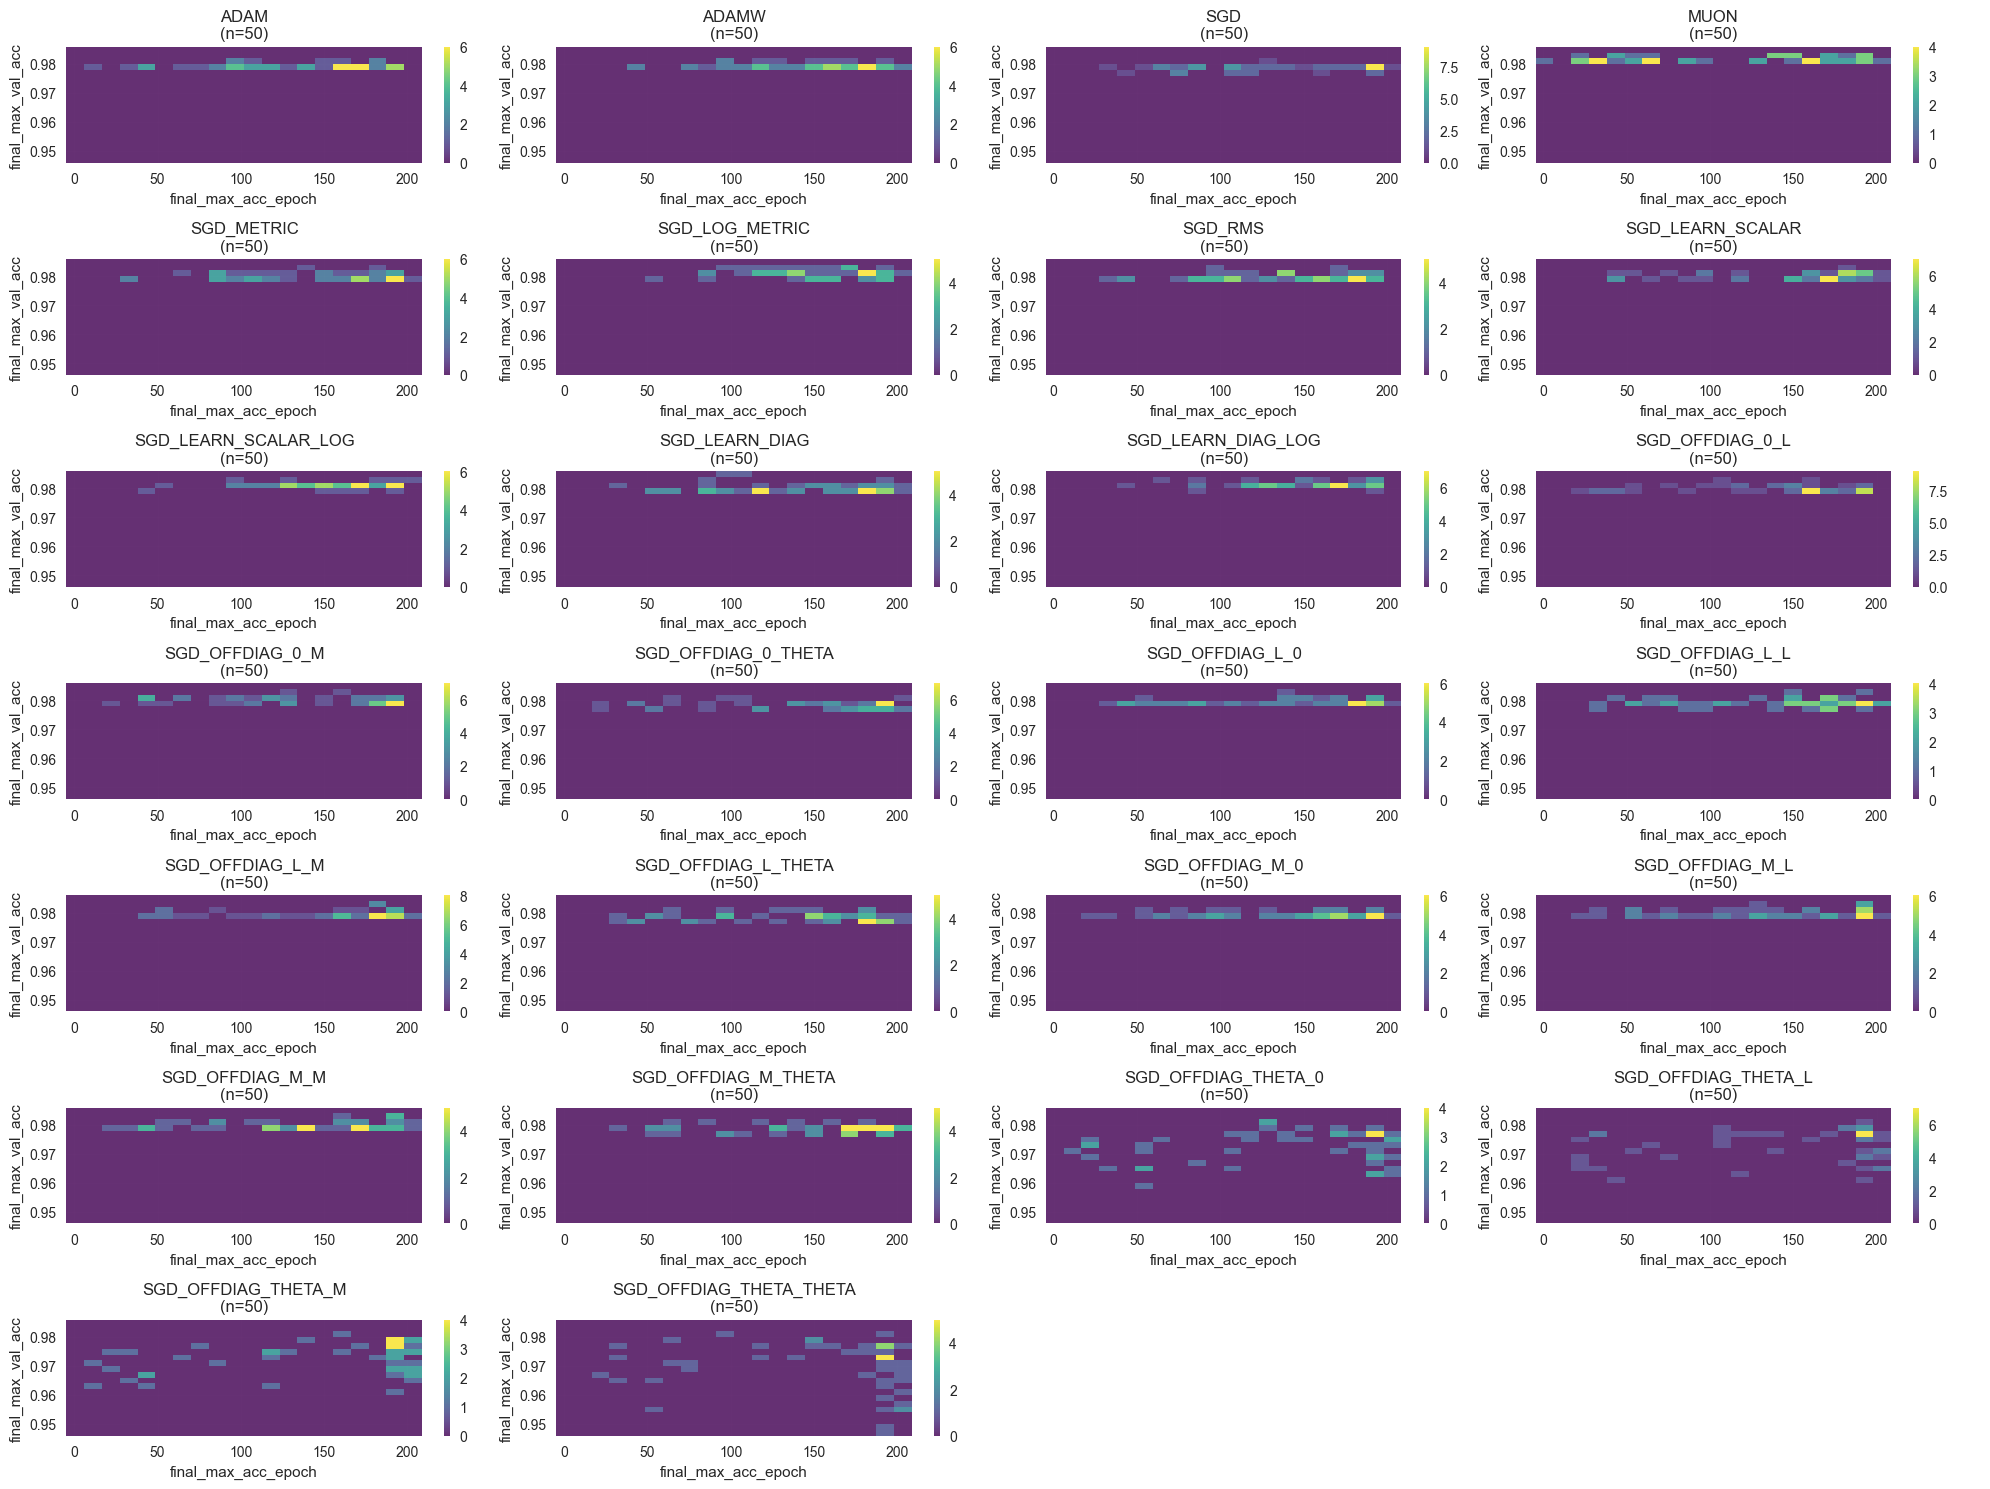

In [4]:
fig = plot_2d_histograms(
    top_n_runs, backend=BACKEND,
    x_metric=HIST_X, y_metric=HIST_Y,
    optimizers=OPTIMIZERS,
)
plt.show()


# Training History


In [5]:
optimizer_data = extract_history(BACKEND, best_runs, HISTORY_METRICS)
add_wall_times(optimizer_data)

print(f"Extracted history for {len(optimizer_data)} optimizers")


Processing adam...
Processing adamw...
Processing sgd...
Processing muon...
Processing sgd_metric...
Processing sgd_log_metric...
Processing sgd_rms...
Processing sgd_learn_scalar...
Processing sgd_learn_scalar_log...
Processing sgd_learn_diag...
Processing sgd_learn_diag_log...
Processing sgd_offdiag_0_l...
Processing sgd_offdiag_0_m...
Processing sgd_offdiag_0_theta...
Processing sgd_offdiag_l_0...
Processing sgd_offdiag_l_l...
Processing sgd_offdiag_l_m...
Processing sgd_offdiag_l_theta...
Processing sgd_offdiag_m_0...
Processing sgd_offdiag_m_l...
Processing sgd_offdiag_m_m...
Processing sgd_offdiag_m_theta...
Processing sgd_offdiag_theta_0...
Processing sgd_offdiag_theta_l...
Processing sgd_offdiag_theta_m...
Processing sgd_offdiag_theta_theta...
Extracted history for 26 optimizers


Time to reach best metric for each optimizer:
  ADAM                :     1.60s at epoch 186 (test_acc: 0.980900)
  ADAMW               :     1.24s at epoch 145 (test_acc: 0.981200)
  SGD                 :     1.07s at epoch 131 (test_acc: 0.980400)
  MUON                :     1.03s at epoch  52 (test_acc: 0.983900)
  SGD_METRIC          :     1.64s at epoch 182 (test_acc: 0.983400)
  SGD_LOG_METRIC      :     0.93s at epoch 103 (test_acc: 0.983700)
  SGD_RMS             :     0.96s at epoch 101 (test_acc: 0.983000)
  SGD_LEARN_SCALAR    :     1.77s at epoch 187 (test_acc: 0.982700)
  SGD_LEARN_SCALAR_LOG:     0.95s at epoch 100 (test_acc: 0.983900)
  SGD_LEARN_DIAG      :     1.07s at epoch 110 (test_acc: 0.984100)
  SGD_LEARN_DIAG_LOG  :     1.60s at epoch 164 (test_acc: 0.983600)
  SGD_OFFDIAG_0_L     :     0.99s at epoch 102 (test_acc: 0.982600)
  SGD_OFFDIAG_0_M     :     1.28s at epoch 134 (test_acc: 0.982600)
  SGD_OFFDIAG_0_THETA :     1.08s at epoch 110 (test_acc: 0.981000)
  

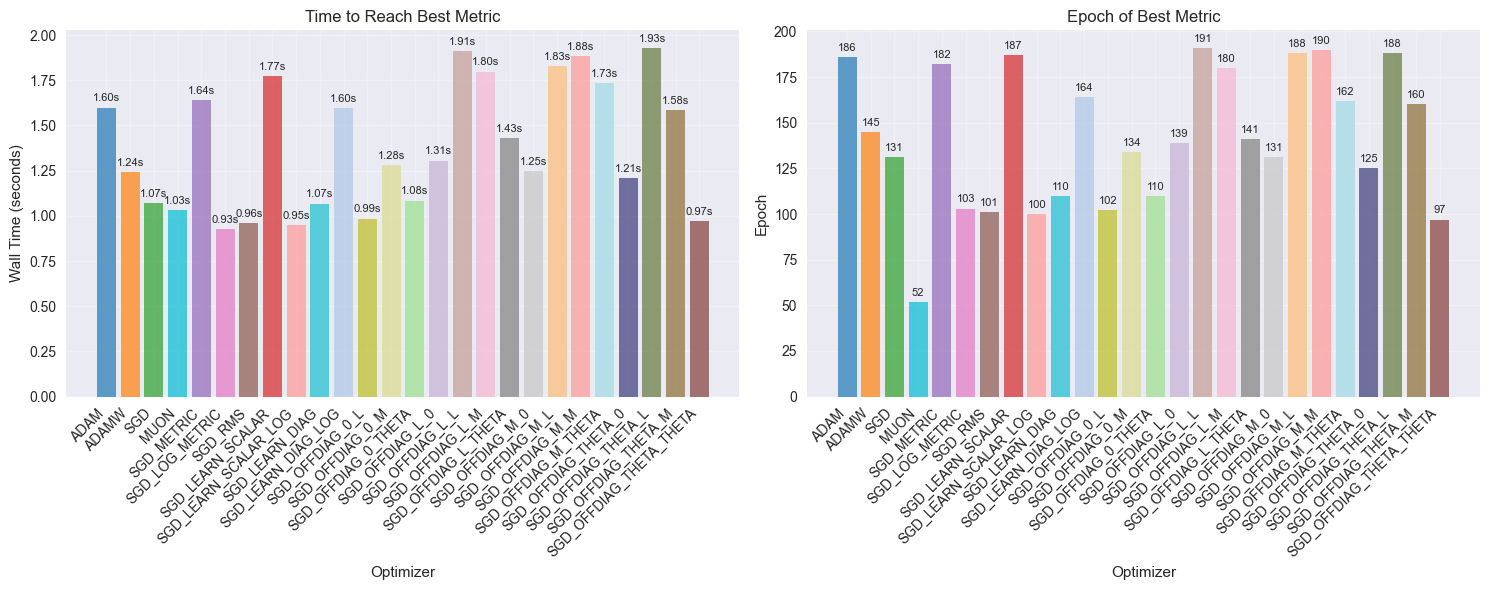

In [6]:
fig = plot_time_to_best(
    best_runs, optimizer_data,
    best_epoch_key=BEST_EPOCH_KEY,
    best_metric_key=BEST_METRIC_KEY,
    colors=colors,
)
plt.show()


# Training Curves


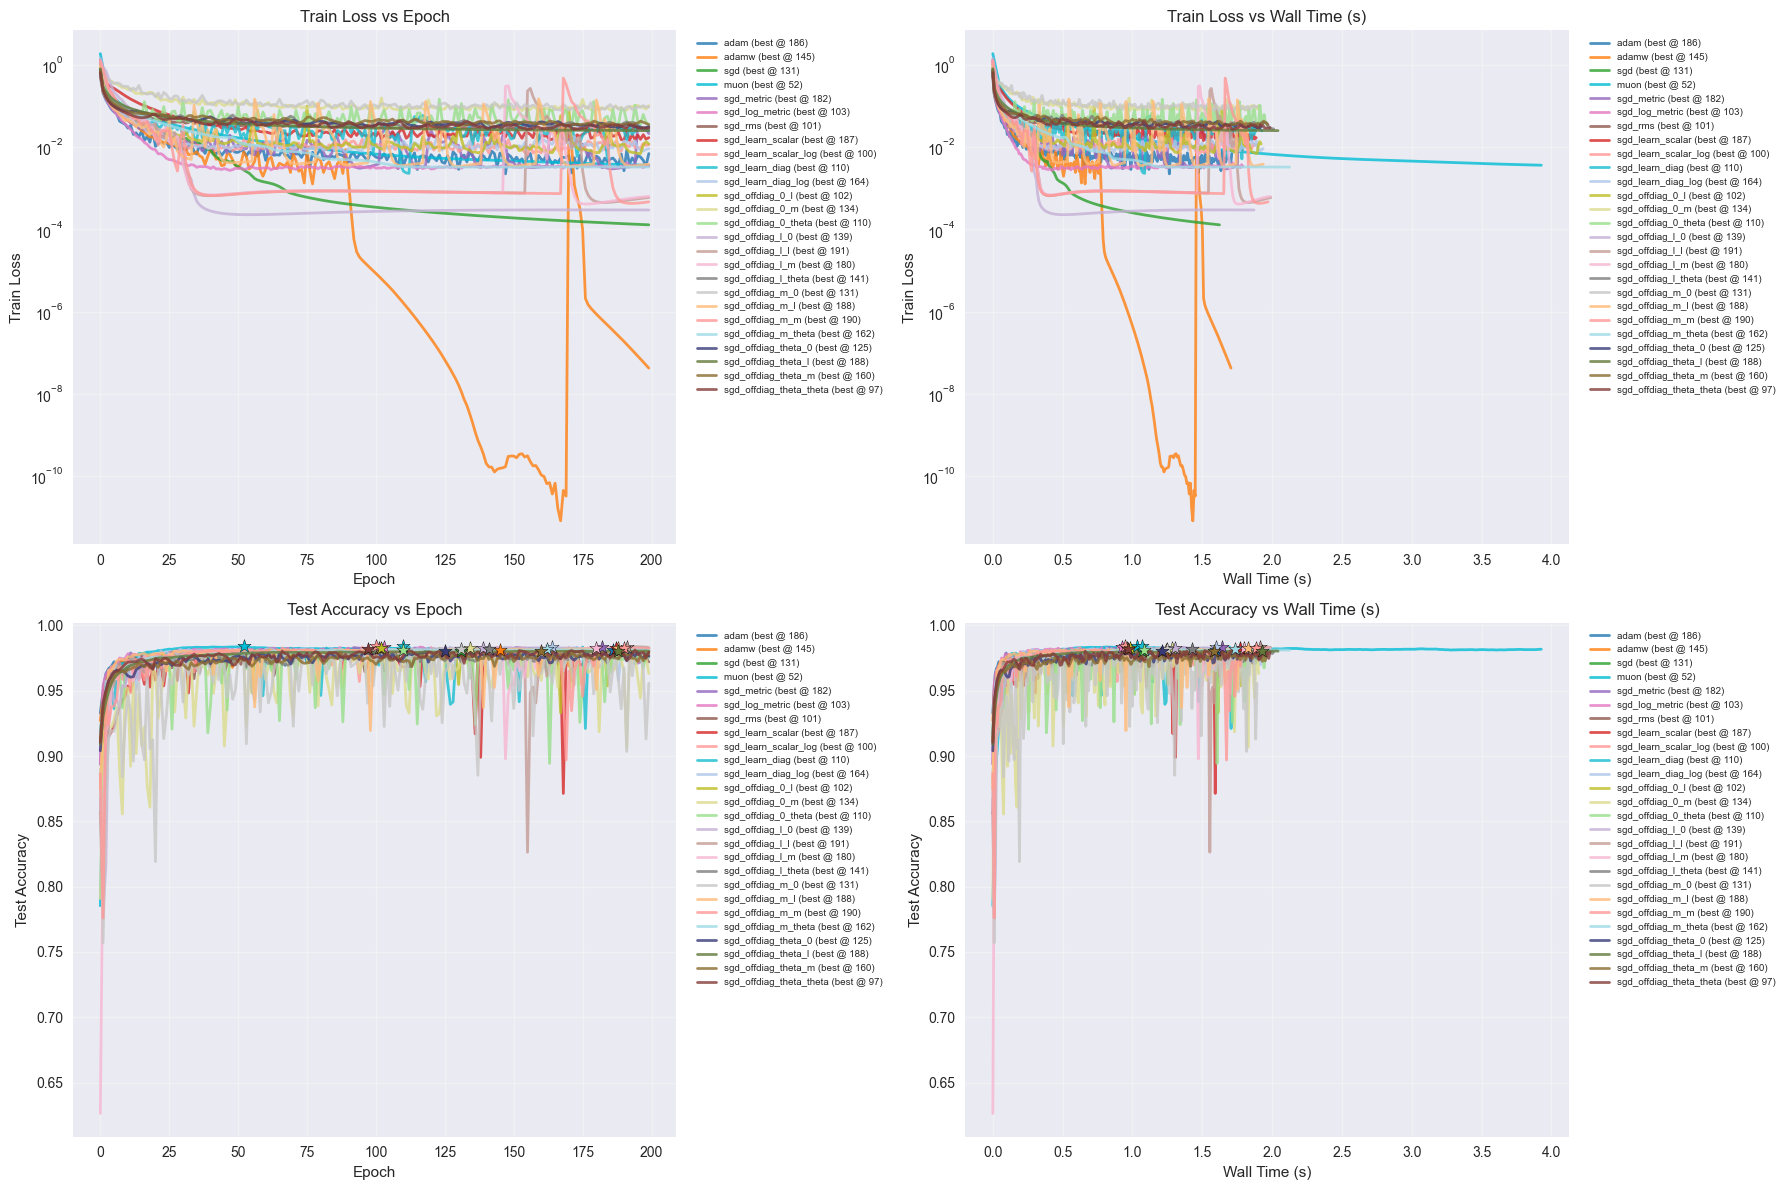

In [7]:
fig = plot_convergence_curves(
    optimizer_data,
    y_keys=["train_loss", "test_acc"],
    x_keys=["epoch", "wall_times"],
    best_runs=best_runs,
    best_epoch_key=BEST_EPOCH_KEY,
    best_metric_key=BEST_METRIC_KEY,
    colors=colors,
    y_labels={"train_loss": "Train Loss", "test_acc": "Test Accuracy"},
    x_labels={"epoch": "Epoch", "wall_times": "Wall Time (s)"},
)
plt.show()

# Speedrun Analysis


Speedrun Results: Time (seconds) to reach target test accuracy
Optimizer                0.85      0.9       0.92      0.94      0.96      0.97      0.975     
-----------------------------------------------------------------------------------------------
adam                     0.0       0.0       0.0       0.0       0.0       0.0       0.1       
adamw                    0.0       0.0       0.0       0.0       0.0       0.1       0.1       
sgd                      0.0       0.0       0.0       0.0       0.0       0.1       0.1       
muon                     0.0       0.0       0.0       0.1       0.1       0.2       0.2       
sgd_metric               0.0       0.0       0.0       0.0       0.0       0.1       0.1       
sgd_log_metric           0.0       0.0       0.0       0.0       0.0       0.1       0.1       
sgd_rms                  0.0       0.0       0.0       0.0       0.0       0.1       0.1       
sgd_learn_scalar         0.0       0.0       0.0       0.1       0.1     

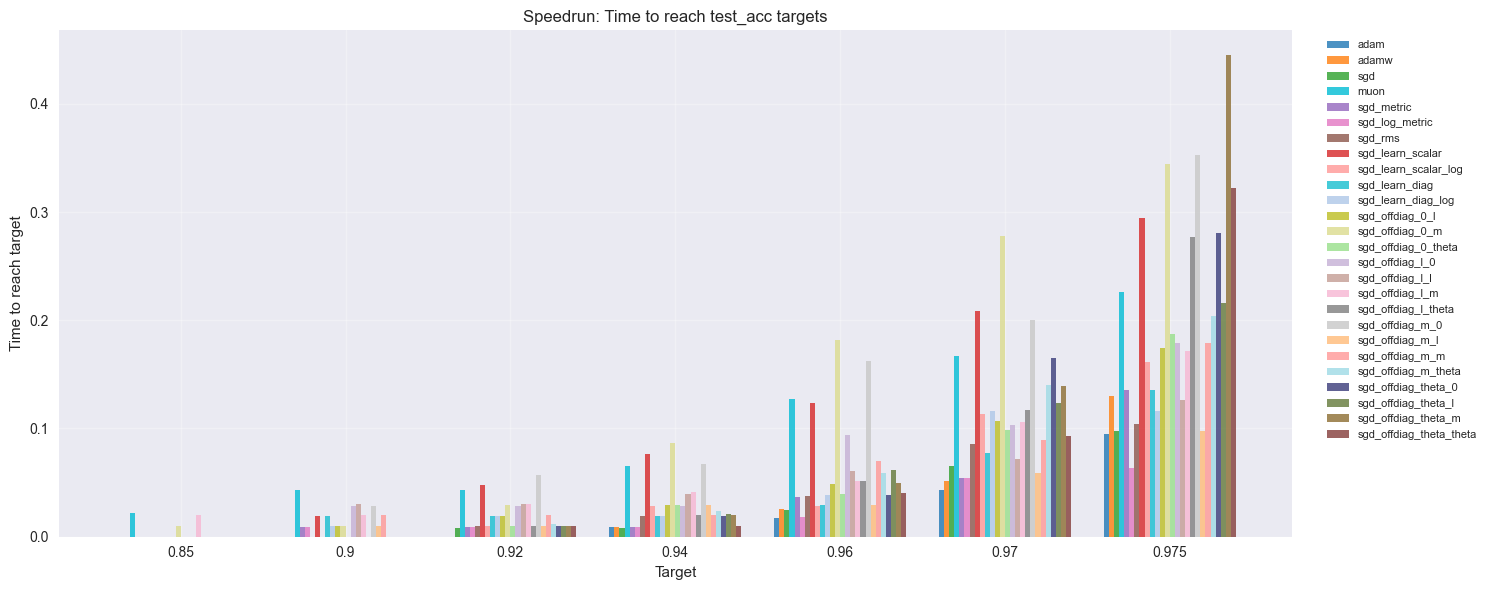

In [8]:
print("Speedrun Results: Time (seconds) to reach target test accuracy")
print("=" * 80)
print_speedrun_table(optimizer_data, SPEEDRUN_TARGETS, SPEEDRUN_METRIC, SPEEDRUN_DIRECTION)

fig = plot_speedrun_results(
    optimizer_data, SPEEDRUN_TARGETS,
    metric_key=SPEEDRUN_METRIC,
    direction=SPEEDRUN_DIRECTION,
    colors=colors,
)
plt.show()


# Performance Summary

/Users/noah-everett/Documents/Research/Induced-Metric-Optimiser/analysis/analysis_utils.py:1666: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/noah-everett/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


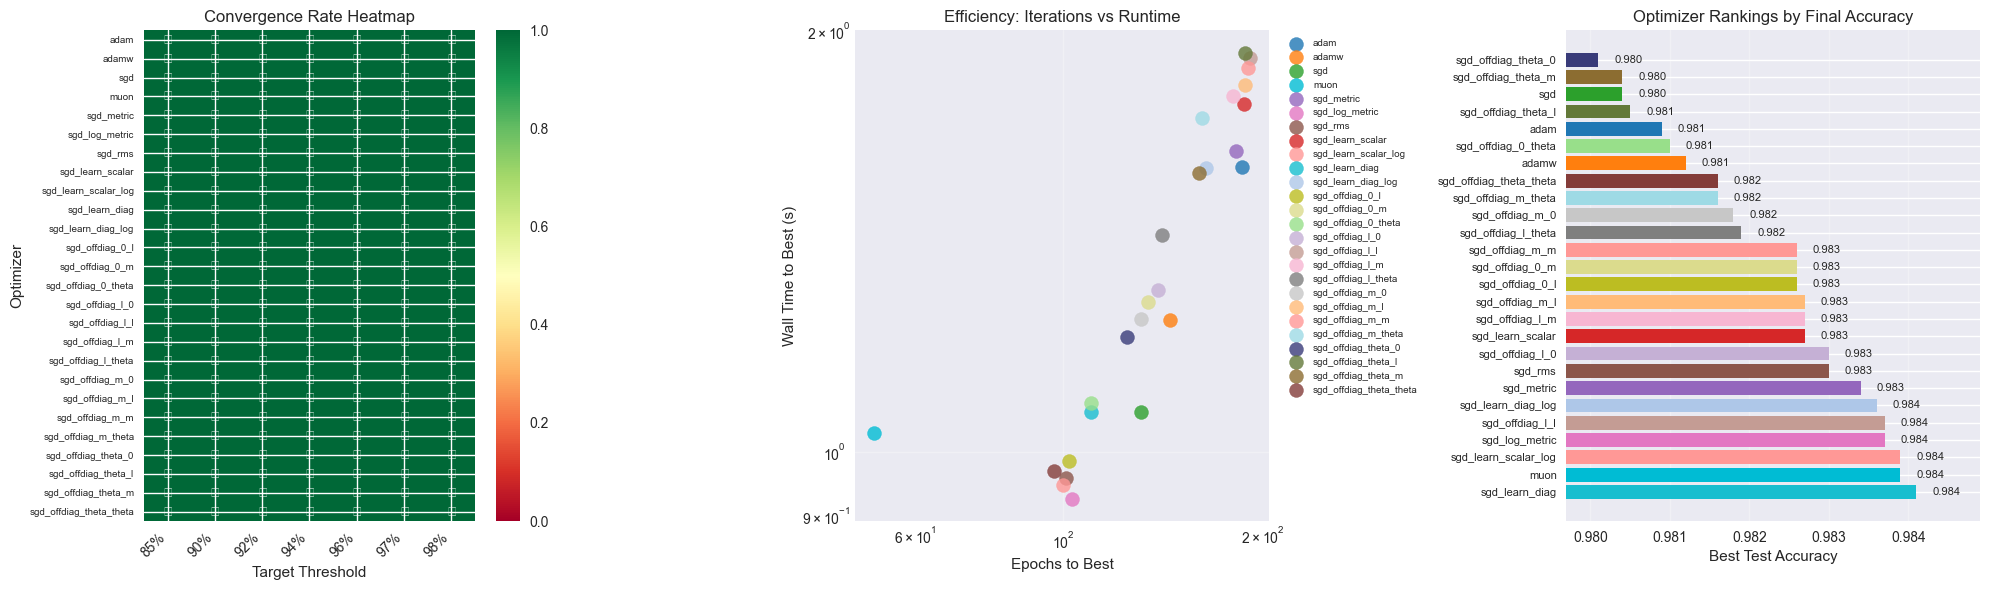

In [9]:
fig = plot_performance_summary(
    best_runs,
    optimizer_data,
    targets=SPEEDRUN_TARGETS,
    metric_key=SPEEDRUN_METRIC,
    direction=SPEEDRUN_DIRECTION,
    epoch_key=BEST_EPOCH_KEY,
    ranking_metric_key="final_max_val_acc",
    colors=colors,
)
plt.show()

# Best Hyperparameters


In [10]:
print_best_hyperparameters(best_runs)

filename = f'best_hyperparameters_MNIST_itr_{ITERATION}.csv'
df = save_best_hyperparameters(best_runs, filename)
df

Hyperparameters for Best Runs

ADAM:
  Run name: run_167
  Config:
    learning_rate: 0.0056581514044715476
    beta1: 0.3064323401234645
    beta2: 0.9626776244394191
    eps: 1e-08
    batch_size: 1024
    n_epochs: 200
  sweep_metric: -0.980900
  final_max_val_acc: 0.980900
----------------------------------------

ADAMW:
  Run name: run_970
  Config:
    learning_rate: 0.0032884482376342094
    beta1: 0.7241714961060847
    beta2: 0.9915277899829948
    eps: 1e-08
    weight_decay: 1.2654063842163958e-05
    batch_size: 1024
    n_epochs: 200
  sweep_metric: -0.981200
  final_max_val_acc: 0.981200
----------------------------------------

SGD:
  Run name: run_98
  Config:
    learning_rate: 0.12069513145865542
    momentum: 0.8881391573530513
    batch_size: 1024
    n_epochs: 200
  sweep_metric: -0.980400
  final_max_val_acc: 0.980400
----------------------------------------

MUON:
  Run name: run_13
  Config:
    learning_rate: 0.006293215187893869
    adam_b1: 0.1395149827250150

,optimizer,run_name,learning_rate,beta1,beta2,eps,batch_size,n_epochs,total_training_time_sec,total_training_time_min,...,adam_b2,beta,xi,beta_rms,metric_lr,metric_reg,metric_clip,gamma,base_mode,use_momentum_for_update
0,adam,run_167,0.005658,0.306432,0.962678,1.000000e-08,1024,200,3.375582,0.056260,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,adamw,run_970,0.003288,0.724171,0.991528,1.000000e-08,1024,200,3.397935,0.056632,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sgd,run_98,0.120695,NaN,NaN,NaN,1024,200,3.218486,0.053641,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,muon,run_13,0.006293,NaN,NaN,1.000000e-08,1024,200,6.358349,0.105972,...,0.960359,0.537201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sgd_metric,run_404,5.543206,NaN,NaN,NaN,1024,200,3.593198,0.059887,...,NaN,0.525606,5.588430,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,sgd_log_metric,run_668,1.674540,NaN,NaN,NaN,1024,200,3.571601,0.059527,...,NaN,0.576674,0.338505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,sgd_rms,run_391,0.056324,NaN,NaN,1.000000e-08,1024,200,3.780514,0.063009,...,NaN,0.504964,0.236943,0.927156,NaN,NaN,NaN,NaN,NaN,NaN
7,sgd_learn_scalar,run_317,0.152522,NaN,NaN,NaN,1024,200,3.728169,0.062136,...,NaN,0.876772,1.032076,NaN,0.067699,0.002419,3.454416,NaN,NaN,NaN
8,sgd_learn_scalar_log,run_488,0.811870,NaN,NaN,NaN,1024,200,3.686092,0.061435,...,NaN,0.651149,0.113863,NaN,0.000423,0.000001,2.087994,NaN,NaN,NaN
9,sgd_learn_diag,run_304,7.728445,NaN,NaN,NaN,1024,200,3.871645,0.064527,...,NaN,0.690846,6.991042,NaN,0.000503,0.000146,1.616580,NaN,NaN,NaN
